# Punto 3 — Estadística descriptiva bivariada

## *"¿Se ven distintos? ¿Qué los relaciona?"*

**Unidad III — Estadística Descriptiva · Diplomatura en Data Analytics (UNNE)**

> **Cómo está armada esta notebook.** Igual que las anteriores: cada concepto viene
> en tres partes — **qué es**, **dónde sirve**, y una sección **⚠️ Forzando el
> concepto** donde lo llevamos hasta que se rompe.
>
> Hasta acá mirábamos **una variable por vez**. Desde este punto miramos siempre
> **dos**. Y aparecen tres errores que son imposibles de cometer mirando de a una:
>
> 1. creer que una correlación alta es un hallazgo,
> 2. creer que un `r` cercano a cero significa "no hay relación",
> 3. buscar valores raros cuando lo raro es la **combinación**.
>
> Los tres los vamos a cometer acá, a propósito, antes de explicarlos.

## 0 · Setup

In [1]:
import os, sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from estadistica import (covarianza, matriz_correlacion, tabla_cruzada,
                         detectar_outliers, comparar_segmentos)

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 110)

RUTA = "../data/raw/housing.csv"
df = pd.read_csv(RUTA)

# La columna derivada que venimos arrastrando desde el punto 1.
df["ambientes_por_hogar"] = df["total_rooms"] / df["households"]

GRUPO, VALOR = "ocean_proximity", "median_house_value"
print(f"{df.shape[0]:,} filas × {df.shape[1]} columnas")

20,640 filas × 11 columnas


## 1 · Covarianza: la primera medida que mira dos columnas

**Qué es.** Para cada fila miramos si `x` está por encima o por debajo de **su**
media, y si `y` está por encima o por debajo de **la suya**. Si las dos se desvían
para el mismo lado, el producto da positivo. La covarianza es el promedio de esos
productos.

```
covarianza = promedio de (x − media_x) · (y − media_y)
```

**El error clásico** es creer que se comparan los valores de `x` con los de `y`.
No: cada uno se compara con **su propio promedio**. Por eso se pueden cruzar
variables en unidades completamente distintas.

**Dónde sirve.** Para saber si dos variables se mueven juntas y en qué sentido.

In [2]:
# A mano, y después contra pandas para verificar.
a_mano = covarianza(df["median_income"], df[VALOR])
pandas_ = df["median_income"].cov(df[VALOR])

print(f"a mano  = {a_mano:>14,.2f}")
print(f"pandas  = {pandas_:>14,.2f}")
print(f"coinciden: {np.isclose(a_mano, pandas_)}")

print("\nEs positiva: los barrios de ingresos altos tienden a tener precios altos.")

a mano  =     150,847.48
pandas  =     150,847.48
coinciden: True

Es positiva: los barrios de ingresos altos tienden a tener precios altos.


#### ⚠️ Forzando el concepto: el mismo par, otra unidad

Ya tenemos el número. La pregunta obvia es: **¿150.847 es mucho o es poco?**

Para contestarla, cambiemos algo que no cambia nada: midamos el precio en **miles**
de dólares en vez de en dólares. Mismos barrios, misma relación, misma realidad.

In [3]:
precio_en_miles = df[VALOR] / 1000

print("precio en dólares →  cov =", f"{covarianza(df['median_income'], df[VALOR]):>12,.2f}")
print("precio en miles   →  cov =", f"{covarianza(df['median_income'], precio_en_miles):>12,.2f}")

print("\nEl número se dividió por 1.000 y en los datos no pasó absolutamente nada.")

precio en dólares →  cov =   150,847.48
precio en miles   →  cov =       150.85

El número se dividió por 1.000 y en los datos no pasó absolutamente nada.


> **La covarianza no se puede leer sola: sólo su signo.** El valor está en las
> unidades de `x` multiplicadas por las de `y` (acá, *dólares × decenas de miles de
> dólares*), que no es una unidad que signifique nada.
>
> Si el problema es la unidad, la solución es sacarle la unidad. Eso es exactamente
> la correlación.

## 2 · Correlación: la covarianza sin unidades

**Qué es.** La covarianza dividida por el desvío de cada variable. Como el desvío
está en las mismas unidades que la variable, las unidades **se cancelan**.

```
correlación = covarianza / (desvío_x · desvío_y)
```

El resultado queda siempre entre −1 y 1:

| valor | qué significa |
|---|---|
| `r = +1` | relación **lineal** perfecta, ascendente |
| `r = 0` | ninguna relación **lineal** |
| `r = −1` | relación **lineal** perfecta, descendente |

Fijate en la palabra **lineal**, que aparece en las tres filas. Es la que se olvida
todo el mundo y la que rompe el análisis en la sección 5.

In [4]:
# La misma prueba de la unidad, ahora con r.
r_dolares = df["median_income"].corr(df[VALOR])
r_miles   = df["median_income"].corr(precio_en_miles)

print(f"precio en dólares →  cov = {covarianza(df['median_income'], df[VALOR]):>12,.2f}   r = {r_dolares:.3f}")
print(f"precio en miles   →  cov = {covarianza(df['median_income'], precio_en_miles):>12,.2f}   r = {r_miles:.3f}")

print("\nLa covarianza cambió 1.000 veces. r no se movió.")

precio en dólares →  cov =   150,847.48   r = 0.688
precio en miles   →  cov =       150.85   r = 0.688

La covarianza cambió 1.000 veces. r no se movió.


> **Por eso `r` se puede leer solo y la covarianza no.** Y por eso podés comparar el
> `r` de dos pares de variables completamente distintas: es un número sin unidades.

## 3 · La matriz de correlación y el heatmap

**Qué es.** El `r` de todos los pares de columnas numéricas, de una sola vez.

**Cómo se lee.** La diagonal siempre vale 1 (cada columna consigo misma) y la matriz
es simétrica, así que alcanza con mirar la mitad de arriba.

**Dónde sirve.** Para decidir **por dónde empezar a mirar**. No para concluir.

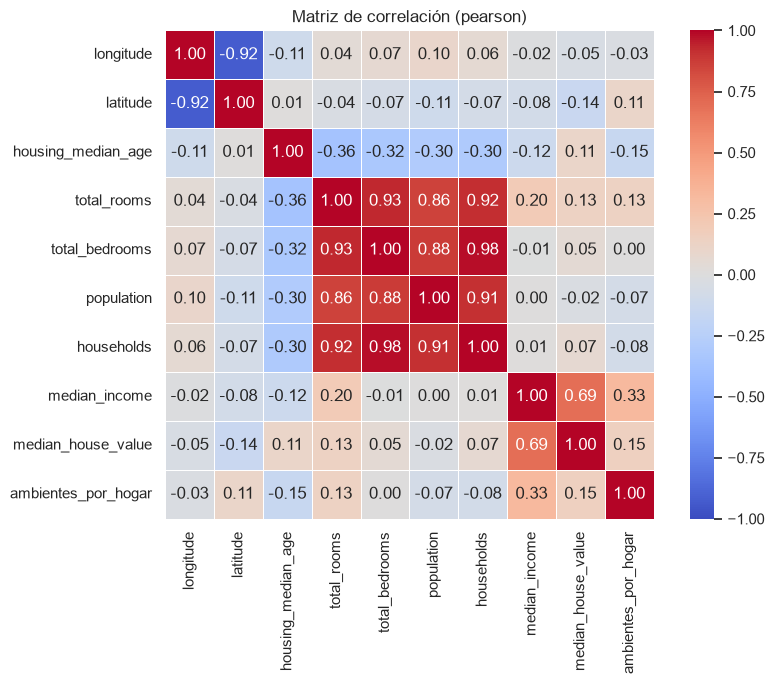

In [5]:
m = matriz_correlacion(df, graficar=True)
plt.show()

> **Sobre `vmin=-1, vmax=1, center=0`:** están fijos a propósito dentro de la
> función. Sin eso, seaborn escala el color al rango de los datos y una correlación
> de 0,3 se pinta del mismo rojo intenso que una de 0,95.

#### ⚠️ Forzando el concepto (1): la correlación más alta no es un hallazgo

Miremos los pares más correlacionados del dataset, ordenados.

In [6]:
# Nos quedamos con la mitad de arriba de la matriz para no repetir pares.
pares = (m.where(np.triu(np.ones(m.shape), k=1).astype(bool))
          .stack().sort_values(key=abs, ascending=False))

print("Los pares más correlacionados del dataset:\n")
for (a, b), r in pares.head(5).items():
    print(f"  {a:<18} × {b:<20} r = {r:.3f}")

print(f"\n  {'median_income':<18} × {VALOR:<20} r = {m.loc['median_income', VALOR]:.3f}")

Los pares más correlacionados del dataset:

  total_bedrooms     × households           r = 0.980
  total_rooms        × total_bedrooms       r = 0.930
  longitude          × latitude             r = -0.925
  total_rooms        × households           r = 0.918
  population         × households           r = 0.907

  median_income      × median_house_value   r = 0.688


Las de arriba son **mucho más fuertes** que la de ingreso contra precio.
¿Descubrimos cuatro relaciones importantísimas? Miremos qué mide cada columna.

In [7]:
print("total_rooms      → habitaciones del barrio")
print("total_bedrooms   → dormitorios del barrio")
print("households       → hogares del barrio")
print("population       → personas del barrio")

# Si las cuatro miden 'cuán grande es el barrio', deberían crecer todas juntas.
chico = df.nsmallest(3, "households")[["households", "total_rooms", "population"]]
grande = df.nlargest(3, "households")[["households", "total_rooms", "population"]]
print("\nLos 3 barrios con MENOS hogares:"); print(chico.to_string(index=False))
print("\nLos 3 barrios con MÁS hogares:");   print(grande.to_string(index=False))

total_rooms      → habitaciones del barrio
total_bedrooms   → dormitorios del barrio
households       → hogares del barrio
population       → personas del barrio

Los 3 barrios con MENOS hogares:
 households  total_rooms  population
        1.0          8.0        13.0
        2.0         49.0        28.0
        2.0          2.0         6.0

Los 3 barrios con MÁS hogares:
 households  total_rooms  population
     6082.0      32627.0     28566.0
     5358.0      39320.0     16305.0
     5189.0      37937.0     16122.0


> **No descubrimos nada: son la misma cosa contada de cuatro maneras.** Un barrio
> con el doble de hogares tiene el doble de habitaciones y el doble de gente.
>
> Y sin embargo `0,980` es el número más alto de toda la matriz. **El heatmap ordena
> por dónde empezar a mirar; no te dice qué es importante.** Esa parte la ponés vos,
> sabiendo qué mide cada columna.

#### ⚠️ Forzando el concepto (2): la columna que la matriz no ve

In [8]:
print("Columnas del dataset          :", df.shape[1])
print("Columnas en la matriz de corr :", m.shape[1])
print("\nLas que faltan:", [c for c in df.columns if c not in m.columns])

Columnas del dataset          : 11
Columnas en la matriz de corr : 10

Las que faltan: ['ocean_proximity']


> Es **el mismo silencio de `.describe()` en el punto 1**: pandas decide por `dtype`,
> y deja afuera justo la variable con la que venimos comparando segmentos.
>
> Segunda vez que nos pasa. Para cruzar una categórica con algo, la herramienta es
> otra — y es la sección que sigue.

## 4 · Cuando las dos variables son categóricas

**La pregunta cambia.** Ya no es *"¿suben juntas?"* —no hay nada que suba— sino
**"¿se reparten distinto?"**.

**La herramienta** es `pd.crosstab()`, que cuenta casos en cada cruce.

In [9]:
# Necesitamos una segunda categórica: partimos el precio en tramos.
# right=False deja los intervalos como [a, b), que es como los leemos al hablar.
df["tramo_precio"] = pd.cut(
    df[VALOR],
    bins=[0, 150_000, 250_000, 500_001, 500_002],
    labels=["bajo", "medio", "alto", "TOPE"],
    right=False,
)
print(df["tramo_precio"].value_counts().sort_index().to_string())

tramo_precio
bajo     7556
medio    7255
alto     4864
TOPE      965


### 4.1 · Primero, los conteos crudos

In [10]:
crudo = pd.crosstab(df[GRUPO], df["tramo_precio"])
crudo["total"] = crudo.sum(axis=1)
print(crudo.to_string())

tramo_precio     bajo  medio  alto  TOPE  total
ocean_proximity                                
<1H OCEAN        1521   4353  2730   532   9136
INLAND           4928   1269   327    27   6551
ISLAND              0      0     5     0      5
NEAR BAY          452    786   858   194   2290
NEAR OCEAN        655    847   944   212   2658


El número más grande de la tabla es el de `INLAND` en el tramo bajo.
**¿Quiere decir que `INLAND` es el grupo con más barrios baratos?**

Sí — y esa no es la pregunta que queremos contestar.

### 4.2 · Ahora normalizado por fila

In [11]:
print(tabla_cruzada(df, GRUPO, "tramo_precio").to_string())

tramo_precio     bajo  medio   alto  TOPE     n
ocean_proximity                                
<1H OCEAN        16.6   47.6   29.9   5.8  9136
INLAND           75.2   19.4    5.0   0.4  6551
ISLAND            0.0    0.0  100.0   0.0     5
NEAR BAY         19.7   34.3   37.5   8.5  2290
NEAR OCEAN       24.6   31.9   35.5   8.0  2658


**Ahora sí hay un hallazgo.** Alrededor de 3 de cada 4 barrios de `INLAND` están en
el tramo bajo, contra menos de 1 de cada 6 en `<1H OCEAN`.

| | qué te dice |
|---|---|
| conteos crudos | qué grupo es más **grande** |
| % por fila | cómo se **comporta** cada grupo |

`INLAND` tenía el número más alto sólo porque tiene 6.551 filas. **Casi siempre la
pregunta es la segunda**, y por eso `tabla_cruzada()` normaliza por fila por defecto.

In [12]:
# Elegir mal el eje da una tabla bien calculada que responde otra pregunta.
print("normalize=\"columns\" — cada COLUMNA suma 100%:")
print(tabla_cruzada(df, GRUPO, "tramo_precio", normalizar="columns").to_string())
print("\nAcá cada columna contesta: \"de los barrios baratos, ¿qué % está en cada zona?\"")
print("Es una pregunta legítima. Simplemente no es la que estábamos haciendo.")

normalize="columns" — cada COLUMNA suma 100%:
tramo_precio     bajo  medio  alto  TOPE     n
ocean_proximity                               
<1H OCEAN        20.1   60.0  56.1  55.1  9136
INLAND           65.2   17.5   6.7   2.8  6551
ISLAND            0.0    0.0   0.1   0.0     5
NEAR BAY          6.0   10.8  17.6  20.1  2290
NEAR OCEAN        8.7   11.7  19.4  22.0  2658

Acá cada columna contesta: "de los barrios baratos, ¿qué % está en cada zona?"
Es una pregunta legítima. Simplemente no es la que estábamos haciendo.


#### ⚠️ Forzando el concepto: el 100% que no vale nada

In [13]:
t = tabla_cruzada(df, GRUPO, "tramo_precio")
print(t.loc[["ISLAND"]].to_string())
print()
print(df[df[GRUPO] == "ISLAND"][[VALOR, "housing_median_age", "population"]].to_string())

tramo_precio     bajo  medio   alto  TOPE  n
ocean_proximity                             
ISLAND            0.0    0.0  100.0   0.0  5

      median_house_value  housing_median_age  population
8314            450000.0                27.0       744.0
8315            414700.0                52.0      1100.0
8316            300000.0                52.0       733.0
8317            450000.0                52.0       341.0
8318            287500.0                29.0       422.0


> **El 100% son cinco barrios.** Es la tercera vez en la unidad que `ISLAND` parece
> ganar: en el punto 2 tenía la media más alta y el CV más bajo, y acá tiene el único
> 100% de la tabla.
>
> **Un porcentaje esconde su `n`.** Por eso `tabla_cruzada()` agrega la columna `n`
> sola y no te deja olvidarla. Cuánto desconfiar exactamente es lo que vamos a poder
> calcular recién en el punto 5.

## 5 · El scatter: el dato sin resumir

`r` es un resumen y, como todo resumen, **pierde información**. El punto 2 nos enseñó
a preguntar siempre lo mismo: ¿qué se pierde acá?

El scatter no resume nada: dibuja un punto por fila. Es lo más cerca del dato crudo
que vas a estar.

#### ⚠️ Forzando el concepto (1): un `r` de casi cero que esconde una relación enorme

In [14]:
# ¿La ubicación norte-sur explica el precio en California?
r_lat = df["latitude"].corr(df[VALOR])
print(f"r (latitude, {VALOR}) = {r_lat:.3f}")
print("\nPrácticamente cero. La lectura obvia: \"la latitud no tiene nada que ver\".")

r (latitude, median_house_value) = -0.144

Prácticamente cero. La lectura obvia: "la latitud no tiene nada que ver".


In [15]:
# Ahora abramos por franja de latitud y miremos la mediana de cada una.
df["franja_lat"] = df["latitude"].astype(int)
franjas = (df.groupby("franja_lat")[VALOR]
             .agg(n="size", mediana="median")
             .query("n > 300"))
print(franjas.to_string())

               n   mediana
franja_lat                
32          1310  158300.0
33          4848  194100.0
34          5134  199500.0
35           522   83650.0
36          1253   89600.0
37          4486  238600.0
38          2082  139500.0
39           593   96900.0
40           334   81750.0


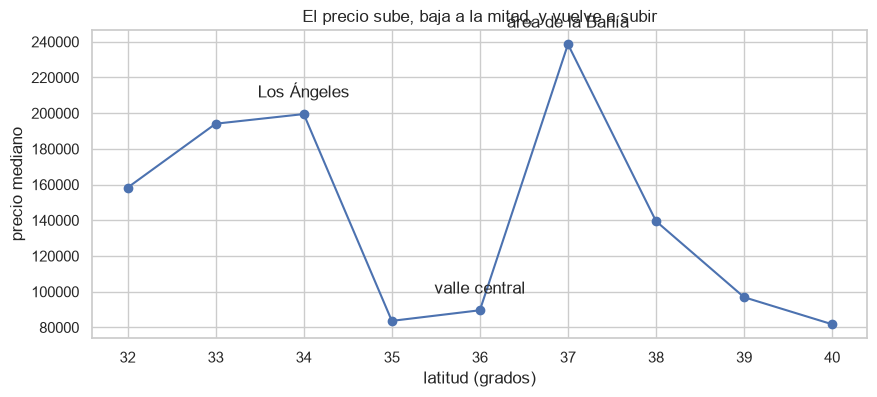

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(franjas.index, franjas["mediana"], marker="o")
ax.set_xlabel("latitud (grados)"); ax.set_ylabel("precio mediano")
ax.set_title("El precio sube, baja a la mitad, y vuelve a subir")
for x, etiqueta in [(34, "Los Ángeles"), (36, "valle central"), (37, "área de la Bahía")]:
    if x in franjas.index:
        ax.annotate(etiqueta, (x, franjas.loc[x, "mediana"]),
                    textcoords="offset points", xytext=(0, 12), ha="center")
plt.show()

> **`r` mide una sola cosa: cuánto se parecen los puntos a UNA RECTA.** Acá no hay
> una recta, hay una eme. Los tramos que suben y los que bajan se cancelan entre sí,
> y el promedio de esa cancelación es el −0,144 que vimos.
>
> **Un `r` de 0 puede significar "no hay relación" o "hay una relación fuerte que no
> es una recta", y son cosas completamente distintas.** Nunca reportes un `r` sin
> haber mirado el gráfico.

#### ⚠️ Forzando el concepto (2): la correlación que desaparece

Del heatmap: `total_rooms × population` da **0,857**. Altísimo, y esta vez no tiene
nada de absurdo: suena obvio que los barrios con más habitaciones tengan más gente.

**¿Más habitaciones atraen más gente, o más gente hace que se construyan más
habitaciones?** Elegí una antes de correr la celda que sigue.

In [17]:
# En vez de 'cuánto hay en el barrio', midamos 'cuánto hay POR HOGAR'.
df["personas_por_hogar"] = df["population"] / df["households"]

r_crudo = df["total_rooms"].corr(df["population"])
r_hogar = df["ambientes_por_hogar"].corr(df["personas_por_hogar"])

print(f"r (total_rooms,        population)        = {r_crudo:>7.3f}")
print(f"r (ambientes_por_hogar, personas_por_hogar) = {r_hogar:>7.3f}")
print("\nLa relación desapareció.")

r (total_rooms,        population)        =   0.857
r (ambientes_por_hogar, personas_por_hogar) =  -0.005

La relación desapareció.


> **Ninguna de las dos opciones era correcta. No hay relación entre ambientes y
> gente: nunca la hubo.**
>
> Lo que estábamos midiendo era **el tamaño del barrio**. Un barrio con el doble de
> hogares tiene el doble de habitaciones *y* el doble de gente, y eso solo alcanza
> para producir un `r` de 0,857.
>
> ```
> tamaño del barrio
>    /           \
>   /             \
> total_rooms ···· population        ← la línea de abajo es la sombra
>        (r = 0,857)                    de las dos flechas de arriba
> ```
>
> **Una correlación espuria no es una casualidad: es una variable que no está en el
> gráfico.** Por eso no la cazás mirando el número —0,857 es tan creíble como
> cualquier otro—, la cazás preguntándote qué **más** podría estar moviendo a las dos
> al mismo tiempo.

#### ⚠️ Forzando el concepto (3): el pairplot que no se puede mirar

columnas numéricas: 12
paneles de un pairplot completo: 144

Por eso se eligen 3 o 4 a mano:


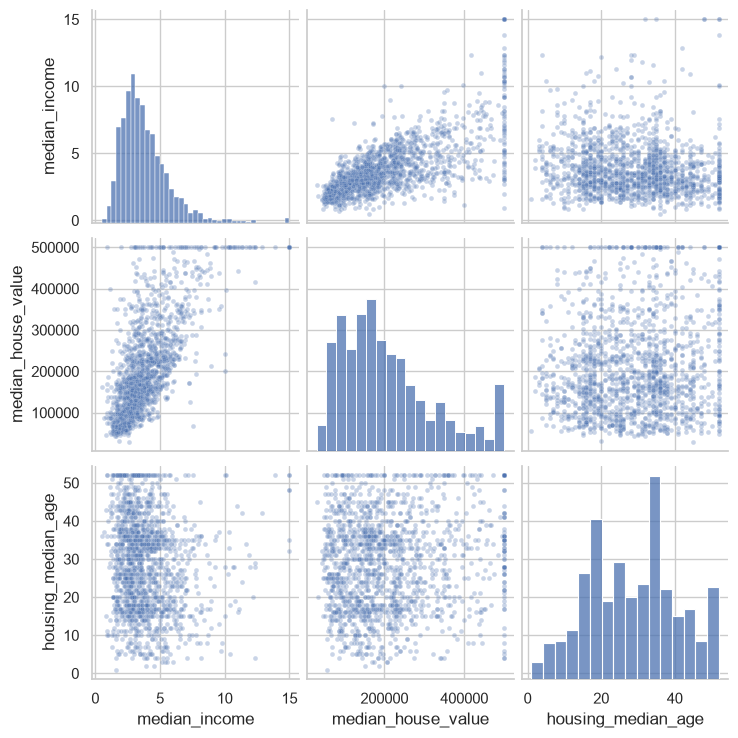

In [18]:
numericas = df.select_dtypes('number').columns
print(f"columnas numéricas: {len(numericas)}")
print(f"paneles de un pairplot completo: {len(numericas)**2}")
print("\nPor eso se eligen 3 o 4 a mano:")

sns.pairplot(df.sample(1500, random_state=42)[["median_income", VALOR,
                                               "housing_median_age"]],
             diag_kind="hist", plot_kws={"alpha": 0.3, "s": 12})
plt.show()

> El pairplot sirve para **barrer** un dataset nuevo en 30 segundos. No sirve para
> mostrarle nada a nadie, ni siquiera a vos mismo dentro de una semana.
>
> *Explorar* y *comunicar* son dos trabajos distintos con dos gráficos distintos. Eso
> es todo el punto 4.

## 6 · Valores atípicos

**La regla del IQR** reusa los cuartiles del punto 2: se mide el rango
intercuartílico `IQR = Q3 − Q1` y se considera atípico todo lo que caiga a más de
`k` veces el IQR por fuera de las cajas.

In [19]:
for k in (1.5, 3.0):
    at, lo, hi = detectar_outliers(df, VALOR, k=k, devolver_limites=True)
    del_tope = (at[VALOR] >= 500_001).sum()
    print(f"k = {k}:  {len(at):>5} atípicos ({len(at)/len(df):>5.1%})  | límite superior = {hi:>9,.0f}")
    if len(at):
        print(f"          de esos, {del_tope} son el tope de 500.001 ({del_tope/len(at):.0%})")

k = 1.5:   1071 atípicos ( 5.2%)  | límite superior =   482,412
          de esos, 965 son el tope de 500.001 (90%)
k = 3.0:      0 atípicos ( 0.0%)  | límite superior =   700,100


#### ⚠️ Forzando el concepto (1): no hay opción tibia

Con `k = 1,5` marcás más de mil casos, y **9 de cada 10 son el tope de 500.001** —
un problema de calidad que ya conocíamos desde el punto 1. Con `k = 3` no marcás
ninguno.

> **El 1,5 que trae todo el mundo por defecto es una convención, no un resultado.**

#### ⚠️ Forzando el concepto (2): el atípico que ninguna regla univariada ve

En el punto 1 apareció esta fila y la dejamos pendiente.

In [20]:
peor = df.nlargest(1, "ambientes_por_hogar").iloc[0]

print(f"ambientes_por_hogar = {peor['ambientes_por_hogar']:.1f}\n")
for col in ["total_rooms", "households", "population"]:
    valor = peor[col]
    pct = (df[col] < valor).mean() * 100
    marca = "   ← normalísimo" if 10 < pct < 90 else ""
    print(f"  {col:<14} {valor:>8,.0f}   percentil {pct:>5.1f}{marca}")

ambientes_por_hogar = 141.9

  total_rooms       1,561   percentil  29.3   ← normalísimo
  households           11   percentil   0.3
  population           30   percentil   0.3


> **En `total_rooms` este barrio es más chico que el 71% del resto.** Ninguna regla
> que mire de a una columna lo iba a marcar por esa columna.
>
> **El valor no es raro. El par es imposible.** 1.561 ambientes es normal; 1.561
> ambientes con 11 hogares no puede ser.
>
> Este es el argumento de por qué existe el punto 3: hay problemas que literalmente
> no se pueden ver mirando de a una variable.

### 6.1 · La foto completa: comparar segmentos

                      n      media   mediana      moda     desvio    cv       min        q1        q3       max  % del total
ocean_proximity                                                                                                             
ISLAND              5.0  380440.00  414700.0  450000.0   80559.56  0.21  287500.0  300000.0  450000.0  450000.0          0.0
NEAR BAY         2290.0  259212.31  233800.0  500001.0  122818.54  0.47   22500.0  162500.0  345700.0  500001.0         11.1
NEAR OCEAN       2658.0  249433.98  229450.0  500001.0  122477.15  0.49   22500.0  150000.0  322750.0  500001.0         12.9
<1H OCEAN        9136.0  240084.29  214850.0  500001.0  106124.29  0.44   17500.0  164100.0  289100.0  500001.0         44.3
INLAND           6551.0  124805.39  108500.0  112500.0   70007.91  0.56   14999.0   77500.0  148950.0  500001.0         31.7


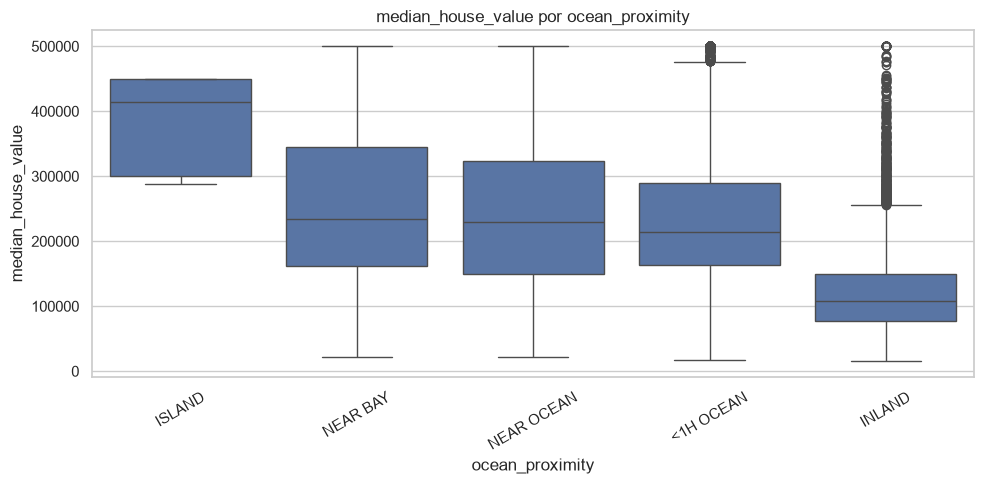

In [21]:
print(comparar_segmentos(df, GRUPO, VALOR).round(2).to_string())
plt.show()

## 7 · Lo que hay que llevarse del punto 3

1. **La covarianza sólo se lee por el signo**; `r` se lee solo porque no tiene unidades.
2. **Una correlación altísima puede ser una tautología** (`total_bedrooms × households` = 0,980).
3. Para cat × cat la herramienta es `crosstab`, **normalizado por fila**.
4. **Un porcentaje sin su `n` no se reporta.** El 100% de `ISLAND` son 5 filas.
5. **`r` sólo ve rectas.** Un `r` de 0 puede esconder una relación fortísima.
6. **Una correlación espuria es una variable que no está en el gráfico.**
7. **Hay atípicos que sólo existen como par**, no como valor.